In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
from GCN import GCN
from GraphSAGE import GraphSAGE
from GAT import GAT
from torch_geometric.datasets import Planetoid
from torch_geometric.loader import DataLoader
import numpy as np
import random
import time
from sklearn.metrics import f1_score, accuracy_score


/home/hice1/pmaji3/scratch/gnn02/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)

cuda


In [4]:
## Instantiate the ExperimentTracker
from results_manager import ExperimentTracker

tracker = ExperimentTracker(dataset_name="PubMed", node_feature_type="PyG")

In [5]:
args = {
      'device': device,
      'num_layers': 3,
      'hidden_dim': 256,
      'dropout': 0.3,
      'lr': 0.01,
      'epochs': 100,
      'opt': 'adam',
      'opt_scheduler': 'none',
      'weight_decay': 0,
      'opt_decay_step': 1,
      'opt_decay_rate':0,
      'opt_restart':0,
      'training_batch_size': 1,
      'test_batch_size': 1,
      'val_batch_size': 1,
      #heads for GAT
      'heads': 2
  }

In [6]:
dataset = Planetoid(root ='tmp/PubMed', name='PubMed', split='full', num_train_per_class=20, num_val=500, num_test=1000)

In [7]:
num_features = dataset.num_features
num_classes = dataset.num_classes
num_nodes = dataset[0].num_nodes
num_edges = dataset[0].num_edges

print(f"Number of graphs in dataset: {len(dataset)}")
print(f"Number of features for each node: {num_features}")
print(f"Number of num_classes : {num_classes}")

print(f"Number of num_nodes : {num_nodes}")
print(f"Number of num_edges : {num_edges}")

Number of graphs in dataset: 1
Number of features for each node: 500
Number of num_classes : 3
Number of num_nodes : 19717
Number of num_edges : 88648


In [8]:
def train(model, data, optimizer, criterion):
    """
    one training epoch
    model -  GNN (GCNConv or GraphSAGE)
    data - Entire Graph Dataset i.e. dataset[0]
    optimizer - algorithm that updates model weights (Adam, SGD, etc.)
    criterion - loss function (often BCEWithLogitsLoss for the PPI dataset)
    """
    #Training mode
    model.train()
    #TODO: Move the data to device outside the training loop
    #data = data.to(device)
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    
    return loss.item()

In [9]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def test(model, data, mask, return_preds=False):
    """
    data: dataset[0] - 1 entire graph composed of all labeled train, test, val
    mask: array of [True, False, ....]
    """
    #switch to evaluation mode
    model.eval()
    # ys: Ground Truth Labels, preds: model predictions across all batches
    ys, preds = [], []

    with torch.no_grad():
        out = model(data.x, data.edge_index)
    pred = out[mask].argmax(dim=1).cpu().numpy()
    y = data.y[mask].cpu().numpy()
    
    #macro - how model handles small classes
    f1 = f1_score(y, pred, average='macro', zero_division=0)
    acc = accuracy_score(y, pred)
    if return_preds:
        return f1, acc, y, pred
    return f1, acc
        

In [10]:
def train_and_evaluate(model, data, optimizer, scheduler, criterion, model_name, epochs=100):
    best_val_f1 = 0
    train_losses, val_f1s, val_accs, test_f1s, test_accs = [],[],[],[],[]
    training_time = 0

    for epoch in range(1, epochs+1):
        start_time = time.time()

        loss = train(model, data, optimizer, criterion)
        
        if scheduler:
            scheduler.step()

        epoch_time = time.time() - start_time
        training_time += epoch_time

        val_f1, val_acc = test(model, data, data.val_mask)
        test_f1, test_acc = test(model, data, data.test_mask)


        train_losses.append(loss)
        val_f1s.append(val_f1)
        test_f1s.append(test_f1)
        val_accs.append(val_acc)
        test_accs.append(test_acc)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save(model.state_dict(), 'best_model_gcn.pth')

        tracker.log_epoch(model_name=model_name, epoch=epoch, loss=loss, val_f1=val_f1, val_acc=val_acc)
        if epoch % 1 == 0:
            print(f"Epoch: {epoch:03d}, "
                f"Loss: {loss:.4f}, "
                f"Val F1: {val_f1:.4f},"
                f"Val Acc: {val_acc:.4f}, "
                f"Time: {epoch_time:.2f}s"
                )


    model.load_state_dict(torch.load('best_model_gcn.pth', map_location=device))

    test_f1, test_acc,y_true, y_pred = test(model, data, data.test_mask, return_preds=True)
    
    #test_f1, test_acc = test(model, data, data.test_mask[:,split_idx])
    print(f"Test F1: {test_f1:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")

    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] # Normalize

    plt.figure(figsize=(5, 5))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', 
                xticklabels=range(5), yticklabels=range(5))
    plt.title('Normalized Confusion Matrix: Roman Empire Syntactic Roles')
    plt.xlabel('Predicted Class')
    plt.ylabel('True Class')
    plt.show()
    
    tracker.save_results(
        model_name=model_name, 
        test_f1=test_f1, 
        test_acc=test_acc,
        params=args # Assuming 'args' contains your hyperparams
    )
    
    return model, train_losses, val_f1s, test_f1s, training_time

In [11]:
def build_optimizer(args, params):
    
    filter_fn = filter(lambda p : p.requires_grad, params)
    weight_decay = args['weight_decay']
    if args['opt'] == 'adam':
        optimizer = torch.optim.Adam(filter_fn, lr=args['lr'], weight_decay=weight_decay)
    elif args['opt'] == 'sgd':
        optimizer = torch.optim.SGD(filter_fn, lr=args['lr'], momentum=0.95, weight_decay=weight_decay)
    elif args['opt'] == 'rmsprop':
        optimizer = torch.optim.RMSprop(filter_fn, lr=args['lr'], weight_decay=weight_decay)
    elif args['opt'] == 'adagrad':
        optimizer = torch.optim.Adagrad(filter_fn, lr=args['lr'], weight_decay=weight_decay)
    if args['opt_scheduler'] == 'none':
        return None, optimizer
    elif args['opt_scheduler'] == 'step':
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=args['opt_decay_step'], gamma=args['opt_decay_rate'])
    elif args['opt_scheduler'] == 'cos':
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=args['opt_restart'])
    return scheduler, optimizer

In [12]:
import matplotlib.pyplot as plt
def plot_results(results, title, label, ylabel):
    plt.figure(figsize=(3,2))
    epochs = range(1, len(results)+1)
    plt.plot(epochs, results, label = label)
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel(ylabel)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.show()

In [13]:
def gcn_run():
    model = GCN(in_channels=num_features, hidden_channels=args['hidden_dim'], 
                out_channels=num_classes, num_layers=args['num_layers'], 
                dropout=args['dropout']).to(device)
    criterion = torch.nn.CrossEntropyLoss()
    scheduler, optimizer = build_optimizer(args, model.parameters())
    
    data = dataset[0].to(device)

    print("Training GCN")
    trained_model, train_losses, val_f1s, test_f1s, training_time  = train_and_evaluate(
        model, 
        data, 
        optimizer,
        scheduler, 
        criterion, 
        model_name="GCN",
        epochs=args["epochs"])
    print("Training Time", training_time)

    plot_results(train_losses, 'Training Loss', 'Graph','Loss')

    plot_results(val_f1s, 'Validation F1 Score', 'GCN','F1 Score')

    plot_results(test_f1s, 'Test F1 Score', 'GCN','F1 Score')


Training GCN
Epoch: 001, Loss: 1.2981, Val F1: 0.2029,Val Acc: 0.4180, Time: 0.34s
Epoch: 002, Loss: 0.6657, Val F1: 0.5022,Val Acc: 0.6740, Time: 0.01s
Epoch: 003, Loss: 0.6198, Val F1: 0.2072,Val Acc: 0.4000, Time: 0.01s
Epoch: 004, Loss: 0.5464, Val F1: 0.1864,Val Acc: 0.3880, Time: 0.01s
Epoch: 005, Loss: 0.4705, Val F1: 0.1864,Val Acc: 0.3880, Time: 0.01s
Epoch: 006, Loss: 0.4553, Val F1: 0.1864,Val Acc: 0.3880, Time: 0.01s
Epoch: 007, Loss: 0.4531, Val F1: 0.1966,Val Acc: 0.3940, Time: 0.01s
Epoch: 008, Loss: 0.4223, Val F1: 0.2840,Val Acc: 0.4520, Time: 0.01s
Epoch: 009, Loss: 0.4047, Val F1: 0.3319,Val Acc: 0.4900, Time: 0.02s
Epoch: 010, Loss: 0.3971, Val F1: 0.3271,Val Acc: 0.4860, Time: 0.01s
Epoch: 011, Loss: 0.3940, Val F1: 0.3100,Val Acc: 0.4720, Time: 0.01s
Epoch: 012, Loss: 0.3877, Val F1: 0.2894,Val Acc: 0.4560, Time: 0.01s
Epoch: 013, Loss: 0.3809, Val F1: 0.2946,Val Acc: 0.4600, Time: 0.01s
Epoch: 014, Loss: 0.3778, Val F1: 0.3366,Val Acc: 0.4940, Time: 0.01s
Epoch: 

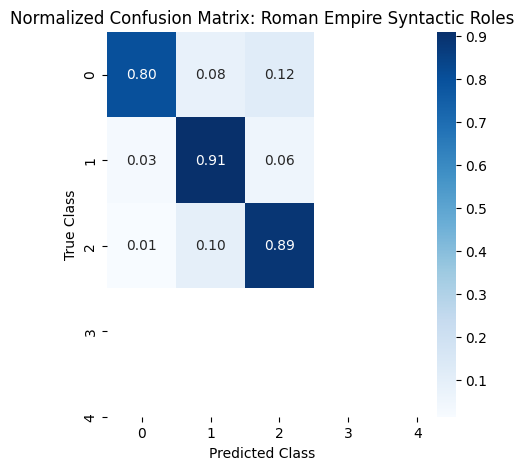

GCN results saved using PyG features.
Training Time 1.3713555335998535


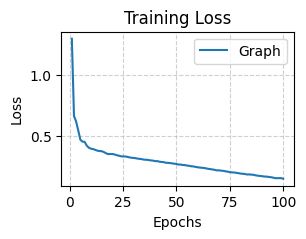

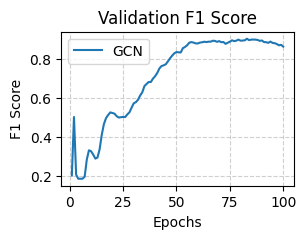

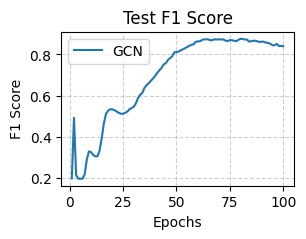

In [14]:
gcn_run()

In [15]:
def graphSage_run():
    model = GraphSAGE(in_channels=num_features, hidden_channels=args['hidden_dim'], 
                out_channels=num_classes, num_layers=args['num_layers'], 
                dropout=args['dropout']).to(device)
    criterion = torch.nn.CrossEntropyLoss()
    scheduler, optimizer = build_optimizer(args, model.parameters())
    data = dataset[0].to(device)
    print("Training Graph SAGE")
    trained_model, train_losses, val_f1s, test_f1s, training_time  = train_and_evaluate(
        model, 
        data,
        optimizer,
        scheduler, 
        criterion,
        model_name="GraphSAGE", 
        epochs=args["epochs"])
    print("Training Time", training_time)

    plot_results(train_losses, 'Training Loss', 'GraphSAGE','Loss')

    plot_results(val_f1s, 'Validation F1 Score', 'GraphSAGE','F1 Score')

    plot_results(test_f1s, 'Test F1 Score', 'GraphSAGE','F1 Score')


Training Graph SAGE
Epoch: 001, Loss: 1.2105, Val F1: 0.1959,Val Acc: 0.4160, Time: 0.02s
Epoch: 002, Loss: 0.7565, Val F1: 0.6711,Val Acc: 0.6600, Time: 0.01s
Epoch: 003, Loss: 0.9747, Val F1: 0.6061,Val Acc: 0.6120, Time: 0.01s
Epoch: 004, Loss: 0.5533, Val F1: 0.5492,Val Acc: 0.5860, Time: 0.01s
Epoch: 005, Loss: 0.5609, Val F1: 0.4706,Val Acc: 0.6100, Time: 0.01s
Epoch: 006, Loss: 0.5261, Val F1: 0.6005,Val Acc: 0.7160, Time: 0.01s
Epoch: 007, Loss: 0.4811, Val F1: 0.6218,Val Acc: 0.7280, Time: 0.01s
Epoch: 008, Loss: 0.5040, Val F1: 0.6483,Val Acc: 0.7460, Time: 0.01s
Epoch: 009, Loss: 0.4595, Val F1: 0.6846,Val Acc: 0.7400, Time: 0.01s
Epoch: 010, Loss: 0.4334, Val F1: 0.6766,Val Acc: 0.7240, Time: 0.01s
Epoch: 011, Loss: 0.4315, Val F1: 0.6895,Val Acc: 0.7280, Time: 0.01s
Epoch: 012, Loss: 0.4230, Val F1: 0.6988,Val Acc: 0.7400, Time: 0.01s
Epoch: 013, Loss: 0.4014, Val F1: 0.7094,Val Acc: 0.7560, Time: 0.01s
Epoch: 014, Loss: 0.3827, Val F1: 0.7225,Val Acc: 0.7760, Time: 0.01s


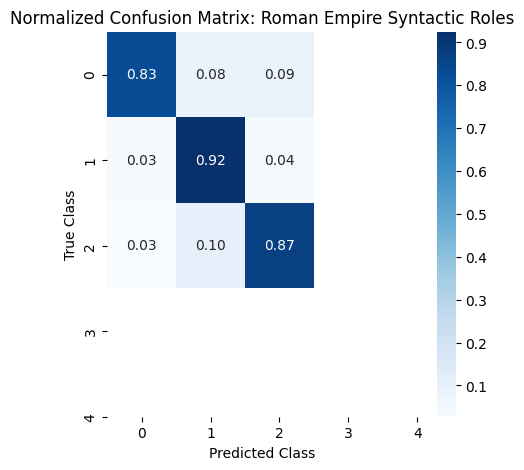

GRAPHSAGE results saved using PyG features.
Training Time 0.9458103179931641


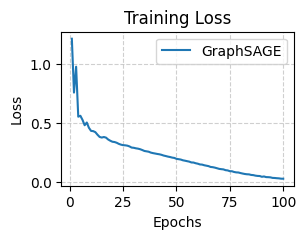

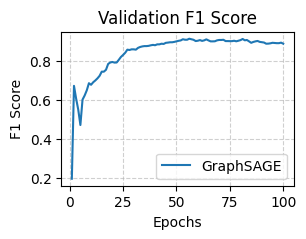

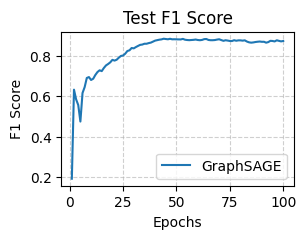

In [16]:
graphSage_run()

In [17]:
def gat_run():
    model = GAT(in_channels=num_features, hidden_channels=args['hidden_dim'], 
                out_channels=num_classes, num_layers=args['num_layers'],
                heads=args['heads'],
                dropout=args['dropout']).to(device)
    criterion = torch.nn.CrossEntropyLoss()
    scheduler, optimizer = build_optimizer(args, model.parameters())
    data = dataset[0].to(device)
    print("Training GAT")
    trained_model, train_losses, val_f1s, test_f1s, training_time  = train_and_evaluate(
        model, 
        data, 
        optimizer,
        scheduler, 
        criterion,
        model_name="GAT", 
        epochs=args["epochs"])
    print("Training Time", training_time)

    plot_results(train_losses, 'Training Loss', 'GAT','Loss')

    plot_results(val_f1s, 'Validation F1 Score', 'GAT','F1 Score')

    plot_results(test_f1s, 'Test F1 Score', 'GAT','F1 Score')


Training GAT
Epoch: 001, Loss: 1.4142, Val F1: 0.3532,Val Acc: 0.5160, Time: 0.04s
Epoch: 002, Loss: 1.2983, Val F1: 0.4191,Val Acc: 0.5640, Time: 0.02s
Epoch: 003, Loss: 2.5341, Val F1: 0.3350,Val Acc: 0.4780, Time: 0.02s
Epoch: 004, Loss: 0.7859, Val F1: 0.4894,Val Acc: 0.5320, Time: 0.02s
Epoch: 005, Loss: 0.7128, Val F1: 0.5201,Val Acc: 0.5480, Time: 0.02s
Epoch: 006, Loss: 0.7331, Val F1: 0.5443,Val Acc: 0.5660, Time: 0.02s
Epoch: 007, Loss: 0.6897, Val F1: 0.6160,Val Acc: 0.6340, Time: 0.02s
Epoch: 008, Loss: 0.6561, Val F1: 0.6552,Val Acc: 0.6900, Time: 0.02s
Epoch: 009, Loss: 0.6422, Val F1: 0.6391,Val Acc: 0.7020, Time: 0.02s
Epoch: 010, Loss: 0.6287, Val F1: 0.5085,Val Acc: 0.6360, Time: 0.02s
Epoch: 011, Loss: 0.6095, Val F1: 0.3590,Val Acc: 0.5140, Time: 0.02s
Epoch: 012, Loss: 0.5932, Val F1: 0.2101,Val Acc: 0.4020, Time: 0.02s
Epoch: 013, Loss: 0.5722, Val F1: 0.2034,Val Acc: 0.3980, Time: 0.02s
Epoch: 014, Loss: 0.5672, Val F1: 0.2034,Val Acc: 0.3980, Time: 0.02s
Epoch: 

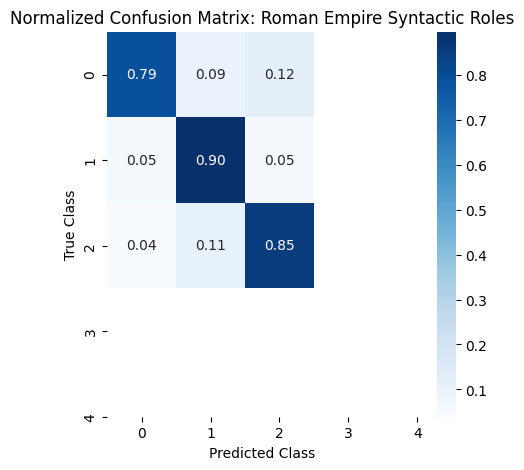

GAT results saved using PyG features.
Training Time 2.2907042503356934


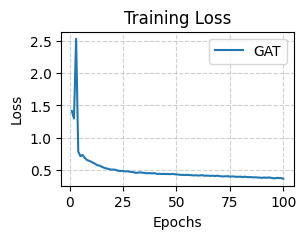

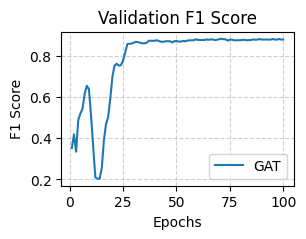

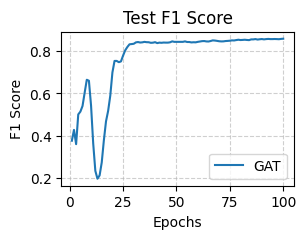

In [18]:
gat_run()

In [19]:
from GCN2 import GCN2

In [20]:
args = {
      'device': device,
      'num_layers': 10,
      'hidden_dim': 256,
      'dropout': 0.5,
      'lr': 0.001,
      'epochs': 400,
      'opt': 'adam',
      'opt_scheduler': 'none',
      'weight_decay': 5e-4,
      'opt_decay_step': 1,
      'opt_decay_rate':0,
      'opt_restart':0,
      'training_batch_size': 1,
      'test_batch_size': 1,
      'val_batch_size': 1,
      'alpha': 0.1,
      'theta':0.5,
      #heads for GAT
      'heads': 2,
      #heterophilous split of the training / val / test
      'split_idx': 1
  }

In [21]:
def gcn2_run():
    model = GCN2(in_channels=num_features, hidden_channels=args['hidden_dim'], 
                out_channels=num_classes, num_layers=args['num_layers'], 
                dropout=args['dropout'], alpha=args['alpha'], theta=args['theta']).to(device)
    criterion = torch.nn.CrossEntropyLoss()
    scheduler, optimizer = build_optimizer(args, model.parameters())
    
    data = dataset[0].to(device)

    print("Training GCN")
    trained_model, train_losses, val_f1s, test_f1s, training_time  = train_and_evaluate(
        model, 
        data, 
        optimizer,
        scheduler, 
        criterion, 
        model_name="GCN2",
        epochs=args["epochs"])
    print("Training Time", training_time)

    plot_results(train_losses, 'Training Loss', 'Graph','Loss')

    plot_results(val_f1s, 'Validation F1 Score', 'GCN2','F1 Score')

    plot_results(test_f1s, 'Test F1 Score', 'GCN2','F1 Score')


Training GCN
Epoch: 001, Loss: 1.1510, Val F1: 0.1959,Val Acc: 0.4160, Time: 0.06s
Epoch: 002, Loss: 1.1162, Val F1: 0.1959,Val Acc: 0.4160, Time: 0.06s
Epoch: 003, Loss: 1.0788, Val F1: 0.1959,Val Acc: 0.4160, Time: 0.06s
Epoch: 004, Loss: 1.0515, Val F1: 0.1959,Val Acc: 0.4160, Time: 0.06s
Epoch: 005, Loss: 0.9925, Val F1: 0.1959,Val Acc: 0.4160, Time: 0.06s
Epoch: 006, Loss: 0.9770, Val F1: 0.1959,Val Acc: 0.4160, Time: 0.06s
Epoch: 007, Loss: 0.9254, Val F1: 0.1959,Val Acc: 0.4160, Time: 0.06s
Epoch: 008, Loss: 0.9049, Val F1: 0.1959,Val Acc: 0.4160, Time: 0.06s
Epoch: 009, Loss: 0.8782, Val F1: 0.1959,Val Acc: 0.4160, Time: 0.06s
Epoch: 010, Loss: 0.8568, Val F1: 0.1959,Val Acc: 0.4160, Time: 0.06s
Epoch: 011, Loss: 0.8329, Val F1: 0.1959,Val Acc: 0.4160, Time: 0.06s
Epoch: 012, Loss: 0.8119, Val F1: 0.1959,Val Acc: 0.4160, Time: 0.06s
Epoch: 013, Loss: 0.7814, Val F1: 0.1959,Val Acc: 0.4160, Time: 0.06s
Epoch: 014, Loss: 0.7653, Val F1: 0.1959,Val Acc: 0.4160, Time: 0.06s
Epoch: 

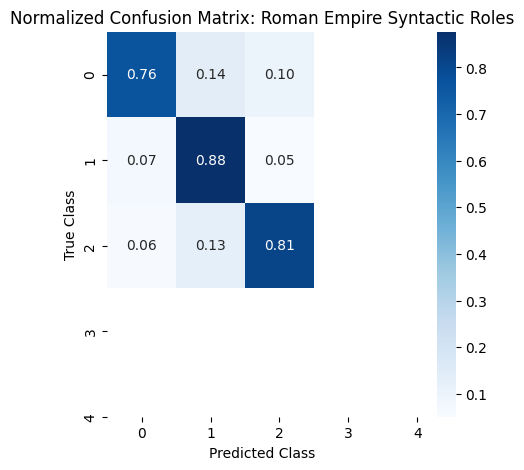

GCN2 results saved using PyG features.
Training Time 20.080822467803955


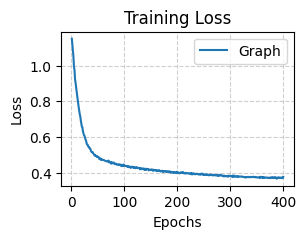

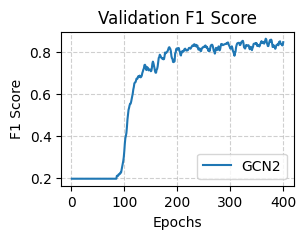

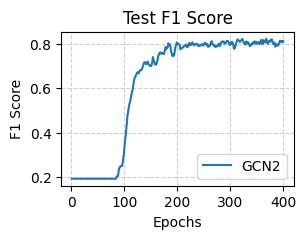

In [22]:
gcn2_run()

In [23]:
from H2GCN import H2GCN

In [24]:
args = {
      'device': device,
      'num_layers': 2, #Not applicable to H2GCN
      'hidden_dim': 30,
      'dropout': 0.5,
      'lr': 0.01,
      'epochs': 30,
      'opt': 'adam',
      'opt_scheduler': 'none',
      'weight_decay': 5e-4,
      'opt_decay_step': 1,
      'opt_decay_rate':0,
      'opt_restart':0,
      'training_batch_size': 1,
      'test_batch_size': 1,
      'val_batch_size': 1,
      'alpha': 0.1,
      'theta':0.5,
      #heads for GAT
      'heads': 2,
      #heterophilous split of the training / val / test
      'split_idx': 1
  }

In [25]:
def h2GCN_run():
    model = H2GCN(in_channels=num_features, hidden_channels=args['hidden_dim'], 
                out_channels=num_classes, 
                dropout=args['dropout']).to(device)
    criterion = torch.nn.CrossEntropyLoss()
    scheduler, optimizer = build_optimizer(args, model.parameters())
    
    data = dataset[0].to(device)

    print("Training H2GCN")
    trained_model, train_losses, val_f1s, test_f1s, training_time  = train_and_evaluate(
        model, 
        data, 
        optimizer,
        scheduler, 
        criterion, 
        model_name="H2GCN",
        epochs=args["epochs"])
    print("Training Time", training_time)

    plot_results(train_losses, 'Training Loss', 'Graph','Loss')

    plot_results(val_f1s, 'Validation F1 Score', 'H2GCN','F1 Score')

    plot_results(test_f1s, 'Test F1 Score', 'H2GCN','F1 Score')


Training H2GCN
Epoch: 001, Loss: 1.1310, Val F1: 0.2770,Val Acc: 0.4400, Time: 0.01s
Epoch: 002, Loss: 1.0024, Val F1: 0.4177,Val Acc: 0.5720, Time: 0.00s
Epoch: 003, Loss: 0.9053, Val F1: 0.4635,Val Acc: 0.6280, Time: 0.00s
Epoch: 004, Loss: 0.8139, Val F1: 0.4725,Val Acc: 0.6400, Time: 0.00s
Epoch: 005, Loss: 0.7346, Val F1: 0.4920,Val Acc: 0.6580, Time: 0.00s
Epoch: 006, Loss: 0.6611, Val F1: 0.5284,Val Acc: 0.6780, Time: 0.00s
Epoch: 007, Loss: 0.6023, Val F1: 0.5584,Val Acc: 0.7040, Time: 0.00s
Epoch: 008, Loss: 0.5507, Val F1: 0.6105,Val Acc: 0.7300, Time: 0.00s
Epoch: 009, Loss: 0.5085, Val F1: 0.6523,Val Acc: 0.7480, Time: 0.00s
Epoch: 010, Loss: 0.4773, Val F1: 0.7263,Val Acc: 0.7840, Time: 0.00s
Epoch: 011, Loss: 0.4574, Val F1: 0.7535,Val Acc: 0.8000, Time: 0.00s
Epoch: 012, Loss: 0.4365, Val F1: 0.8036,Val Acc: 0.8280, Time: 0.00s
Epoch: 013, Loss: 0.4191, Val F1: 0.8290,Val Acc: 0.8420, Time: 0.00s
Epoch: 014, Loss: 0.4066, Val F1: 0.8321,Val Acc: 0.8420, Time: 0.00s
Epoch

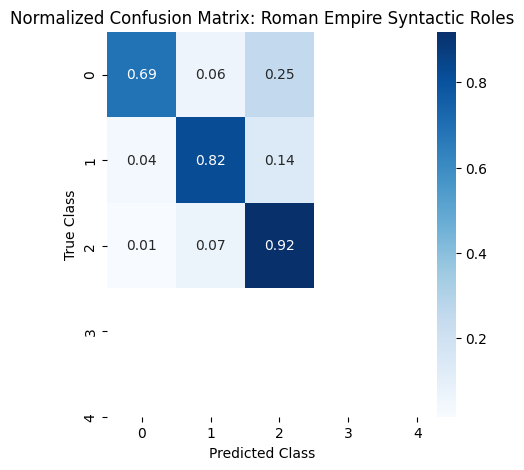

H2GCN results saved using PyG features.
Training Time 0.12031912803649902


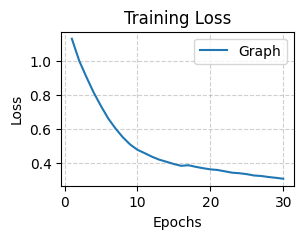

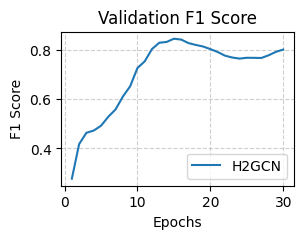

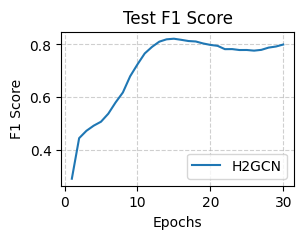

In [26]:
h2GCN_run()